
# Multi-Class Text Classification: News Topic Classification

This notebook follows the instruction: EDA, three preprocessing versions, TF-IDF + ML/DNN, Skip-gram + RNN family models, hyperparameter logging, and final comparison.

**Upgrade note:** This version includes an IEEE-style Dataset & EDA section, controlled augmented vs non-augmented experiments, and final DNN epoch/batch-size tuning for stronger validation performance.


## Notebook Execution Order

Run this notebook from top to bottom in this order:

1. Setup and imports  
2. Load dataset  
3. Raw EDA  
4. Preprocessing functions  
5. Create three preprocessing versions in separate cells  
6. Cleaned-text EDA  
7. Label encoding and train/validation split  
8. Modeling and evaluation  
9. Augmented vs non-augmented comparison  
10. Final model selection and test evaluation

The three preprocessing versions are intentionally separated into different cells to avoid hidden dependency errors and make debugging easier.


## 1. Project Setup

We keep the setup close to the course labs: pandas for data handling, NLTK for preprocessing, sklearn for TF-IDF/ML/evaluation, gensim for Skip-gram Word2Vec, and TensorFlow/Keras for neural models.


In [1]:
import os
import re
import html
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

!pip install gensim
from gensim.models import Word2Vec

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

2026-04-29 07:21:00.356631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777447260.592712      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777447260.668309      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777447261.195069      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777447261.195132      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777447261.195135      23 computation_placer.cc:177] computation placer alr

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

## 2. Load Dataset

The project instruction says the dataset is already split into training and testing CSV files. Use the training file for training/validation and the testing file only for final evaluation. If the test file is not available while practicing, the fallback creates a temporary holdout set from the training data. For final submission, replace `TEST_PATH` with the official test CSV.


In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the latest version of the dataset using the pandas adapter
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shafin11027/newspaper-headline-tag",
  "Training_data_5.csv"
)

print("First 5 records:")
display(df.head())

# Assign to our training variable
train_df = df

/tmp/ipykernel_23/3165195680.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:


,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> New H...,Science and Technology
1,<html> <body> News Headlines:\n <br> <b> Trans...,Sports
2,<html> <body> News Headlines:\n <br> <b> NASA ...,Science and Technology
3,<html> <body> News Headlines:\n <br> <b> Top-s...,Sports
4,<html> <body> News Headlines:\n <br> <b> Shara...,Sports


In [3]:
from sklearn.model_selection import train_test_split

# Splitting the downloaded dataset since we need a test/val set
train_df, test_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["News Topic"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (79244, 2)
Testing shape: (13985, 2)


## 3. Initial Dataset Understanding

The dataset has two columns: `News Headline` as the input text and `News Topic` as the target class. The model learns to map each news headline/body snippet into one of the four topic categories.


In [4]:
print("Columns:", train_df.columns.tolist())
print("\nData types:")
print(train_df.dtypes)
print("\nMissing values in train:")
print(train_df.isnull().sum())
print("\nMissing values in test:")
print(test_df.isnull().sum())
print("\nClass distribution:")
print(train_df["News Topic"].value_counts())

Columns: ['News Headline', 'News Topic']

Data types:
News Headline    object
News Topic       object
dtype: object

Missing values in train:
News Headline    0
News Topic       0
dtype: int64

Missing values in test:
News Headline    0
News Topic       0
dtype: int64

Class distribution:
News Topic
World News                37671
Science and Technology    17109
Business                  12814
Sports                    11650
Name: count, dtype: int64


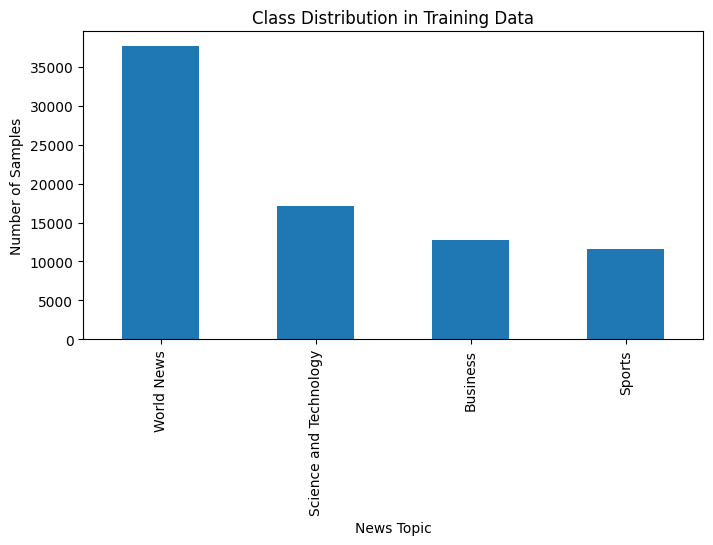

In [5]:
train_df["News Topic"].value_counts().plot(kind="bar", figsize=(8, 4), title="Class Distribution in Training Data")
plt.xlabel("News Topic")
plt.ylabel("Number of Samples")
plt.show()


count    79244.000000
mean        47.101888
std         10.338943
min         17.000000
25%         41.000000
50%         47.000000
75%         52.000000
max        177.000000
Name: raw_word_count, dtype: float64


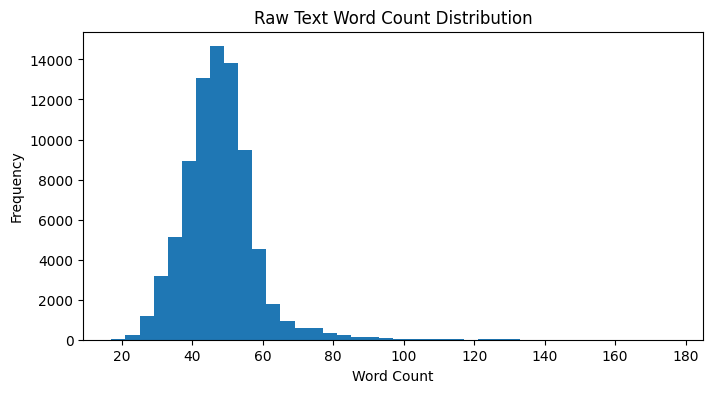

In [6]:
train_df["raw_word_count"] = train_df["News Headline"].astype(str).apply(lambda x: len(x.split()))

print(train_df["raw_word_count"].describe())

train_df["raw_word_count"].plot(kind="hist", bins=40, figsize=(8, 4), title="Raw Text Word Count Distribution")
plt.xlabel("Word Count")
plt.show()


In [7]:
for label in train_df["News Topic"].unique():
    print("\nCLASS:", label)
    sample_text = train_df[train_df["News Topic"] == label]["News Headline"].iloc[0]
    print(sample_text[:700])


CLASS: Science and Technology
<html> <body> News Headlines:
 <br> <b> AMD chips to gain security, virtualization features  SAN FRANCISCO - Advanced Micro Devices (AMD) plans to build security and virtualization features into its server processors by 2006, the company said Friday during its annual analyst event. </b> 
 <br> <br> 

CLASS: Business
<html> <body> News Headlines:
 <br> <b> Disney reaches deal for beleaguered retail chain The Children #39;s Place Retail Stores Inc. announced Wednesday it will buy The Walt Disney Co. #39;s flagging retail chain in an effort to become a bigger player in the infant to preteen market. </b> 
 <br> <br> 

CLASS: Sports
<html> <body> News Headlines:
 <br> <b> Sports in Brief  Two track world records set Pole vaulter Yelena Isinbayeva of Russia and steeplechaser Saif Saaeed Shaheen of Qatar set world records at the Van Damme Memorial meet yesterday in Brussels, Belgium. </b> 
 <br> <br> 

CLASS: World News
<html> <body> News Headlines:
 <br> <b> Pe

## 4. EDA Findings

Important observations from the training data:

1. The task is multi-class classification with four news categories.
2. The dataset is imbalanced: World News appears much more than the other classes. Therefore macro F1 is important because it treats all classes equally.
3. The text contains HTML tags such as `<html>`, `<body>`, `<br>`, and `<b>`. It also contains HTML entities such as `#39;`.
4. Most samples are short news headline/summary texts, so sequence length should not be too large.
5. Extreme preprocessing may remove useful words from short text, so optimum preprocessing should clean HTML/noise but avoid damaging meaning too much.


## IEEE-Style Dataset and EDA Section

### A. Dataset Description

The dataset used in this project is a large-scale multi-class news topic classification corpus. Each record contains a short news headline or headline-style text and its corresponding topic label. The input feature is `News Headline`, while the target variable is `News Topic`. The classification task is therefore formulated as a supervised NLP problem where a model learns to map short textual news content into one of four topic classes: World News, Science and Technology, Business, and Sports.

The dataset is suitable for this project because it represents a realistic short-text classification setting. Unlike long documents, news headlines contain limited context, so the model must rely on compact lexical, semantic, and topic-specific signals. During initial inspection, the dataset also showed noisy textual artifacts such as HTML tags, encoded symbols, punctuation irregularities, and inconsistent casing. These characteristics make it appropriate for comparing different preprocessing strategies and word representation techniques.

### B. Exploratory Data Analysis

Exploratory Data Analysis was performed before model development to understand the dataset structure, target distribution, text quality, and feature characteristics. The dataset contains two main columns: `News Headline` and `News Topic`. Missing value analysis showed that the dataset is structurally complete, meaning no major imputation step is required before training.

The class distribution analysis revealed that the dataset is imbalanced. World News contains the largest number of samples, while Sports contains the smallest number of samples. Because of this imbalance, accuracy alone is not a reliable evaluation metric. A model can achieve high accuracy by favoring the majority class while performing poorly on minority classes. For this reason, macro F1-score is used along with accuracy, confusion matrix, and classification report.

Text length analysis showed that most samples are short and information-dense. This is expected for headline-based classification, but it also increases the difficulty of the task because each text contains fewer contextual clues than a full article. The raw text inspection further showed that preprocessing is necessary because the text includes HTML artifacts and encoded characters. However, excessive preprocessing may remove useful topic-specific signals such as proper nouns, organization names, and domain-specific terms. Therefore, three preprocessing versions are created: no preprocessing, extreme preprocessing, and optimum preprocessing.

Vocabulary-level exploration indicates that the four classes contain distinguishable lexical patterns. Business headlines frequently contain economic and corporate terms, Sports headlines include player, match, and tournament-related words, Science and Technology headlines include research and technology-oriented terms, and World News contains political and international event-related vocabulary. This separation suggests that both TF-IDF and embedding-based neural models can learn meaningful class boundaries.

Overall, the EDA shows that the dataset is appropriate for multi-class text classification, but the model design must handle class imbalance, short-text context limitations, and raw text noise. These findings directly motivate the use of multiple preprocessing pipelines, TF-IDF features, skip-gram embeddings, traditional machine learning, and recurrent neural network architectures.


,count,percentage
News Topic,,
World News,37671,47.54
Science and Technology,17109,21.59
Business,12814,16.17
Sports,11650,14.70


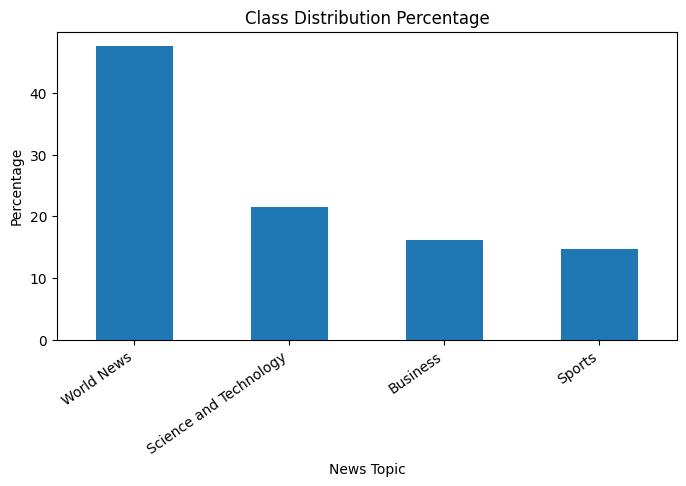

raw_word_count             raw_char_count             
                                 mean median  max           mean median   max
News Topic                                                                   
Business                        46.46   46.0  126         298.92  294.0  1053
Science and Technology          46.16   45.0  177         294.84  288.0  1067
Sports                          46.72   46.0  127         282.45  277.0   811
World News                      47.86   48.0  154         300.40  301.0   923

<Figure size 900x400 with 0 Axes>

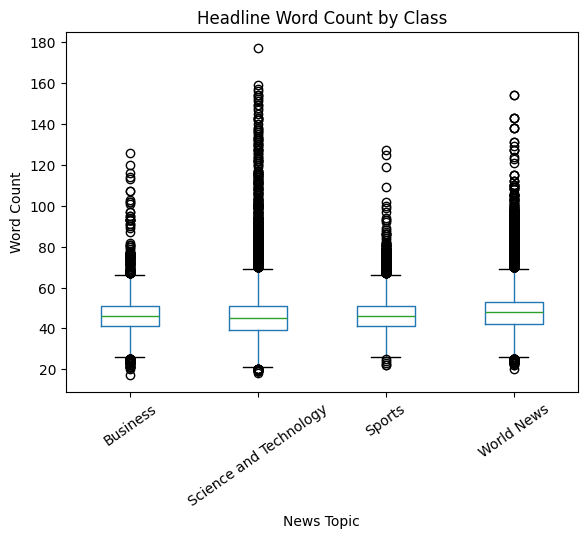

In [8]:
# Extra raw EDA for a stronger report: class percentage and headline length by class

class_counts = train_df["News Topic"].value_counts()
class_percent = (class_counts / class_counts.sum() * 100).round(2)
eda_class_table = pd.DataFrame({"count": class_counts, "percentage": class_percent})
display(eda_class_table)

plt.figure(figsize=(8, 4))
eda_class_table["percentage"].plot(kind="bar", title="Class Distribution Percentage")
plt.ylabel("Percentage")
plt.xlabel("News Topic")
plt.xticks(rotation=35, ha="right")
plt.show()

train_df["raw_char_count"] = train_df["News Headline"].astype(str).apply(len)
length_summary = train_df.groupby("News Topic")[["raw_word_count", "raw_char_count"]].agg(["mean", "median", "max"]).round(2)
display(length_summary)

plt.figure(figsize=(9, 4))
train_df.boxplot(column="raw_word_count", by="News Topic", grid=False, rot=35)
plt.title("Headline Word Count by Class")
plt.suptitle("")
plt.ylabel("Word Count")
plt.show()


## 5. Preprocessing Functions

The project requires three versions: no preprocessing, extreme preprocessing, and optimum preprocessing.


In [9]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

html_tag_pattern = re.compile(r"<.*?>")
non_alpha_pattern = re.compile(r"[^a-zA-Z\s]")
space_pattern = re.compile(r"\s+")

def basic_html_clean(text):
    text = str(text)
    text = html.unescape(text)
    text = re.sub(html_tag_pattern, " ", text)
    text = text.replace("News Headlines:", " ")
    text = re.sub(space_pattern, " ", text).strip()
    return text

def no_preprocessing(text):
    return str(text)

def extreme_preprocessing(text):
    text = basic_html_clean(text)
    text = text.lower()
    text = re.sub(non_alpha_pattern, " ", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(tokens)

def optimum_preprocessing(text):
    text = basic_html_clean(text)
    text = text.lower()
    text = re.sub(non_alpha_pattern, " ", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if len(word) > 2]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)


### 5.1 Dataset Version 1: No Preprocessing

This version keeps the original headline exactly as it appears in the dataset. It is required so we can compare whether cleaning actually improves performance.


In [10]:
train_df["text_no_preprocess"] = train_df["News Headline"].apply(no_preprocessing)
test_df["text_no_preprocess"] = test_df["News Headline"].apply(no_preprocessing)

train_df[["News Headline", "text_no_preprocess", "News Topic"]].head(3)


,News Headline,text_no_preprocess,News Topic
0,<html> <body> News Headlines:\n <br> <b> AMD c...,<html> <body> News Headlines:\n <br> <b> AMD c...,Science and Technology
1,<html> <body> News Headlines:\n <br> <b> Disne...,<html> <body> News Headlines:\n <br> <b> Disne...,Business
2,<html> <body> News Headlines:\n <br> <b> Jack ...,<html> <body> News Headlines:\n <br> <b> Jack ...,Business


### 5.2 Dataset Version 2: Extreme Preprocessing

This version applies aggressive cleaning, stopword removal, and stemming. It is useful for testing whether reducing words to their stems improves classification.


In [11]:
train_df["text_extreme"] = train_df["News Headline"].apply(extreme_preprocessing)
test_df["text_extreme"] = test_df["News Headline"].apply(extreme_preprocessing)

train_df[["News Headline", "text_extreme", "News Topic"]].head(3)


,News Headline,text_extreme,News Topic
0,<html> <body> News Headlines:\n <br> <b> AMD c...,amd chip gain secur virtual featur san francis...,Science and Technology
1,<html> <body> News Headlines:\n <br> <b> Disne...,disney reach deal beleagu retail chain childre...,Business
2,<html> <body> News Headlines:\n <br> <b> Jack ...,jack box post strong sale jack box inc wednesd...,Business


### 5.3 Dataset Version 3: Optimum Preprocessing

This version removes obvious noise but preserves useful meaning through lemmatization. This is usually the strongest version for headline classification because it cleans text without destroying too much context.


In [12]:
train_df["text_optimum"] = train_df["News Headline"].apply(optimum_preprocessing)
test_df["text_optimum"] = test_df["News Headline"].apply(optimum_preprocessing)

train_df[["News Headline", "text_optimum", "News Topic"]].head(3)


,News Headline,text_optimum,News Topic
0,<html> <body> News Headlines:\n <br> <b> AMD c...,amd chip gain security virtualization feature ...,Science and Technology
1,<html> <body> News Headlines:\n <br> <b> Disne...,disney reach deal beleaguered retail chain chi...,Business
2,<html> <body> News Headlines:\n <br> <b> Jack ...,jack box post strong sale jack box inc wednesd...,Business


### 5.4 Preprocessing Comparison Table

The table below shows the same headline under all three preprocessing strategies.


In [13]:
train_df[["News Headline", "text_no_preprocess", "text_extreme", "text_optimum", "News Topic"]].head(5)


,News Headline,text_no_preprocess,text_extreme,text_optimum,News Topic
0,<html> <body> News Headlines:\n <br> <b> AMD c...,<html> <body> News Headlines:\n <br> <b> AMD c...,amd chip gain secur virtual featur san francis...,amd chip gain security virtualization feature ...,Science and Technology
1,<html> <body> News Headlines:\n <br> <b> Disne...,<html> <body> News Headlines:\n <br> <b> Disne...,disney reach deal beleagu retail chain childre...,disney reach deal beleaguered retail chain chi...,Business
2,<html> <body> News Headlines:\n <br> <b> Jack ...,<html> <body> News Headlines:\n <br> <b> Jack ...,jack box post strong sale jack box inc wednesd...,jack box post strong sale jack box inc wednesd...,Business
3,<html> <body> News Headlines:\n <br> <b> Astro...,<html> <body> News Headlines:\n <br> <b> Astro...,astronom readi comet smash mission space com s...,astronomer ready comet smashing mission space ...,Science and Technology
4,<html> <body> News Headlines:\n <br> <b> Consu...,<html> <body> News Headlines:\n <br> <b> Consu...,consum confid plummet august consum confid ris...,consumer confidence plummet august consumer co...,Business


## 5.1 Cleaned Text EDA: Top Words by Class

This section must run **after preprocessing columns are created**.  
The purpose is to inspect meaningful class-specific vocabulary after HTML tags, encoded characters, punctuation, and unnecessary noise are removed.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

def show_top_words_by_class(df, text_col, label_col="News Topic", top_n=15):
    if text_col not in df.columns:
        raise KeyError(f"{text_col} was not found. Run the preprocessing cell before this EDA cell.")

    for label in sorted(df[label_col].unique()):
        subset = df[df[label_col] == label][text_col].astype(str)

        vectorizer = CountVectorizer(stop_words="english", max_features=5000)
        counts = vectorizer.fit_transform(subset)

        word_freq = np.asarray(counts.sum(axis=0)).ravel()
        words = np.array(vectorizer.get_feature_names_out())
        top_idx = word_freq.argsort()[::-1][:top_n]

        print("\nClass:", label)
        display(pd.DataFrame({
            "word": words[top_idx],
            "frequency": word_freq[top_idx]
        }))

show_top_words_by_class(train_df, "text_optimum")



Class: Business


,word,frequency
0,said,3170
1,reuters,2935
2,new,2887
3,oil,2693
4,company,2359
5,price,2299
6,year,1902
7,stock,1872
8,profit,1555
9,york,1510



Class: Science and Technology


,word,frequency
0,new,4078
1,microsoft,3005
2,company,2358
3,software,2129
4,said,2110
5,service,2062
6,internet,1935
7,year,1876
8,reuters,1812
9,computer,1635



Class: Sports


,word,frequency
0,game,2263
1,win,1730
2,team,1651
3,new,1591
4,season,1484
5,year,1483
6,world,1182
7,night,1176
8,cup,1125
9,victory,1118



Class: World News


,word,frequency
0,said,9874
1,iraq,7510
2,reuters,6908
3,president,5480
4,minister,4667
5,new,4531
6,afp,4328
7,killed,3916
8,official,3870
9,say,3760


## 6. Label Encoding and Train/Validation Split

The official test set is kept untouched for final evaluation. Validation data comes only from the training set.


In [15]:
label_encoder = LabelEncoder()
train_df["label"] = label_encoder.fit_transform(train_df["News Topic"])
test_df["label"] = label_encoder.transform(test_df["News Topic"])

num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_

train_part, val_part = train_test_split(
    train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["label"]
)

print("Classes:", list(class_names))
print("Train part:", train_part.shape)
print("Validation part:", val_part.shape)
print("Test part:", test_df.shape)


Classes: ['Business', 'Science and Technology', 'Sports', 'World News']
Train part: (67357, 8)
Validation part: (11887, 8)
Test part: (13985, 6)


## 7. Evaluation Helper

Every model is evaluated using accuracy, macro F1, confusion matrix, and classification report, exactly as required.


In [16]:
results = []
evaluation_tables = {}

def evaluate_model(model_name, preprocess_name, representation_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    results.append({
        "model": model_name,
        "preprocessing": preprocess_name,
        "representation": representation_name,
        "accuracy": acc,
        "macro_f1": macro_f1
    })

    summary_df = pd.DataFrame({
        "Metric": ["Accuracy", "Macro F1"],
        "Score": [acc, macro_f1]
    })

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report_dict).transpose().round(4)

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual: {label}" for label in class_names],
        columns=[f"Predicted: {label}" for label in class_names]
    )

    key = f"{model_name} | {preprocess_name} | {representation_name}"
    evaluation_tables[key] = {
        "summary": summary_df,
        "classification_report": report_df,
        "confusion_matrix": cm_df
    }

    print("Model:", model_name)
    print("Preprocessing:", preprocess_name)
    print("Representation:", representation_name)
    display(summary_df)

    print("Classification Report DataFrame:")
    display(report_df)

    print("Confusion Matrix DataFrame:")
    display(cm_df)

    return acc, macro_f1, cm_df


## 8. TF-IDF + Logistic Regression

Logistic Regression is used as the ML baseline because it is strong for sparse TF-IDF text features, fast to train, and easy to explain in viva.


In [17]:
preprocess_columns = {
    "no_preprocessing": "text_no_preprocess",
    "extreme_preprocessing": "text_extreme",
    "optimum_preprocessing": "text_optimum"
}

best_tfidf_objects = {}

for preprocess_name, text_col in preprocess_columns.items():
    print("\n" + "="*80)
    print("TF-IDF + Logistic Regression:", preprocess_name)

    tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
    X_train = tfidf.fit_transform(train_part[text_col])
    X_val = tfidf.transform(val_part[text_col])

    lr_model = LogisticRegression(max_iter=1000, C=2.0, class_weight="balanced", solver="liblinear")
    lr_model.fit(X_train, train_part["label"])
    val_pred = lr_model.predict(X_val)

    evaluate_model("Logistic Regression", preprocess_name, "TF-IDF", val_part["label"], val_pred)
    best_tfidf_objects[(preprocess_name, "lr")] = (tfidf, lr_model)


TF-IDF + Logistic Regression: no_preprocessing
Model: Logistic Regression
Preprocessing: no_preprocessing
Representation: TF-IDF


,Metric,Score
0,Accuracy,0.919408
1,Macro F1,0.908071


Classification Report DataFrame:


,precision,recall,f1-score,support
Business,0.8486,0.8574,0.8530,1922.0000
Science and Technology,0.8869,0.8866,0.8868,2566.0000
Sports,0.9100,0.9777,0.9426,1748.0000
World News,0.9627,0.9374,0.9499,5651.0000
accuracy,0.9194,0.9194,0.9194,0.9194
macro avg,0.9021,0.9148,0.9081,11887.0000
weighted avg,0.9202,0.9194,0.9195,11887.0000


Confusion Matrix DataFrame:


...

,Metric,Score
0,Accuracy,0.912762
1,Macro F1,0.901033


Classification Report DataFrame:


,precision,recall,f1-score,support
Business,0.8171,0.8621,0.8390,1922.0000
Science and Technology,0.8888,0.8753,0.8820,2566.0000
Sports,0.9071,0.9720,0.9384,1748.0000
World News,0.9613,0.9287,0.9447,5651.0000
accuracy,0.9128,0.9128,0.9128,0.9128
macro avg,0.8936,0.9095,0.9010,11887.0000
weighted avg,0.9144,0.9128,0.9132,11887.0000


Confusion Matrix DataFrame:


,Predicted: Business,Predicted: Science and Technology,Predicted: Sports,Predicted: World News
Actual: Business,1657,183,14,68
Actual: Science and Technology,184,2246,27,109
Actual: Sports,9,6,1699,34
Actual: World News,178,92,133,5248


## 9. TF-IDF + Deep Neural Network

The DNN uses TF-IDF vectors. The first layer has 256 neurons, satisfying the instruction that the deep network should have 128+ neurons in the first layer and at least 3 to 4+ layers.


In [18]:
def build_dnn(input_dim, num_classes, hidden_1=256, hidden_2=128, dropout_rate=0.4, learning_rate=0.001):
    model = Sequential([
        Dense(hidden_1, activation="relu", input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(hidden_2, activation="relu"),
        Dropout(dropout_rate),
        Dense(64, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [19]:
from tensorflow.keras.layers import Input

# Re-defining required variable to fix NameError
preprocess_columns = {
    "no_preprocessing": "text_no_preprocess",
    "extreme_preprocessing": "text_extreme",
    "optimum_preprocessing": "text_optimum"
}

def build_dnn_fixed(input_dim, num_classes, hidden_1=256, hidden_2=128, dropout_rate=0.4, learning_rate=0.001):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(hidden_1, activation="relu"),
        Dropout(dropout_rate),
        Dense(hidden_2, activation="relu"),
        Dropout(dropout_rate),
        Dense(64, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Process one at a time to manage memory
preprocess_name = "no_preprocessing"
text_col = preprocess_columns[preprocess_name]

print(f"\nTraining TF-IDF + DNN on: {preprocess_name}")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train = tfidf.fit_transform(train_part[text_col]).astype("float32").toarray()
X_val = tfidf.transform(val_part[text_col]).astype("float32").toarray()

dnn_model = build_dnn_fixed(input_dim=X_train.shape[1], num_classes=num_classes)
early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

dnn_model.fit(
    X_train,
    train_part["label"].values,
    validation_data=(X_val, val_part["label"].values),
    epochs=8,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

val_pred = np.argmax(dnn_model.predict(X_val), axis=1)
evaluate_model("Deep Neural Network", preprocess_name, "TF-IDF", val_part["label"], val_pred)
best_tfidf_objects[(preprocess_name, "dnn")] = (tfidf, dnn_model)


Training TF-IDF + DNN on: no_preprocessing


I0000 00:00:1777447459.777609      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777447459.783527      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/8


I0000 00:00:1777447468.398389      79 service.cc:152] XLA service 0x7bbcb000b6d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777447468.398443      79 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777447468.398451      79 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777447468.730265      79 cuda_dnn.cc:529] Loaded cuDNN version 91002


 39/527 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4510 - loss: 1.2779

...

,Metric,Score
0,Accuracy,0.919660
1,Macro F1,0.905062


Classification Report DataFrame:


,precision,recall,f1-score,support
Business,0.8445,0.8424,0.8434,1922.0000
Science and Technology,0.8812,0.8761,0.8786,2566.0000
Sports,0.9436,0.9376,0.9406,1748.0000
World News,0.9549,0.9602,0.9576,5651.0000
accuracy,0.9197,0.9197,0.9197,0.9197
macro avg,0.9061,0.9041,0.9051,11887.0000
weighted avg,0.9195,0.9197,0.9196,11887.0000


Confusion Matrix DataFrame:


,Predicted: Business,Predicted: Science and Technology,Predicted: Sports,Predicted: World News
Actual: Business,1619,207,15,81
Actual: Science and Technology,184,2248,25,109
Actual: Sports,21,22,1639,66
Actual: World News,93,74,58,5426


## 10. Skip-gram Word2Vec Preparation

Skip-gram learns dense word vectors by predicting nearby context words. Here, it is trained on the project training text, which keeps the representation dataset-specific and defensible in viva.


In [20]:
MAX_VOCAB_SIZE = 30000
MAX_SEQUENCE_LENGTH = 80
EMBEDDING_DIM = 100

sequence_objects = {}

def prepare_skipgram_sequences(text_col):
    train_texts = train_part[text_col].astype(str).tolist()
    val_texts = val_part[text_col].astype(str).tolist()
    test_texts = test_df[text_col].astype(str).tolist()

    tokenized_train = [text.split() for text in train_texts]
    w2v_model = Word2Vec(
        sentences=tokenized_train,
        vector_size=EMBEDDING_DIM,
        window=5,
        min_count=2,
        sg=1,
        workers=4,
        seed=SEED,
        epochs=10
    )

    tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
    tokenizer.fit_on_texts(train_texts)

    X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_texts), maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
    X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_texts), maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
    X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_texts), maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

    vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
    embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

    for word, index in tokenizer.word_index.items():
        if index >= vocab_size:
            continue
        if word in w2v_model.wv:
            embedding_matrix[index] = w2v_model.wv[word]

    return X_train_seq, X_val_seq, X_test_seq, embedding_matrix, vocab_size, tokenizer, w2v_model


## 11. RNN Model Builder

The same embedding matrix is used for SimpleRNN, GRU, LSTM, and their bidirectional versions. This makes the comparison fair because the representation is constant while the architecture changes.


In [21]:
def build_rnn_model(model_type, vocab_size, embedding_matrix, num_classes, rnn_units=64, dropout_rate=0.4, learning_rate=0.001):
    model = Sequential()
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=True
    ))

    if model_type == "SimpleRNN":
        model.add(SimpleRNN(rnn_units))
    elif model_type == "GRU":
        model.add(GRU(rnn_units))
    elif model_type == "LSTM":
        model.add(LSTM(rnn_units))
    elif model_type == "Bidirectional SimpleRNN":
        model.add(Bidirectional(SimpleRNN(rnn_units)))
    elif model_type == "Bidirectional GRU":
        model.add(Bidirectional(GRU(rnn_units)))
    elif model_type == "Bidirectional LSTM":
        model.add(Bidirectional(LSTM(rnn_units)))

    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


## 12. Skip-gram + All Required RNN Models

This is the heaviest section. For final submission, run every preprocessing version and every architecture. If your machine is slow, run one architecture at a time and save the results table.


## 12A. Complete Skip-gram + RNN Training Grid

The earlier cells prepared the Skip-gram representation and defined the RNN architecture builder. This section performs the missing model training step across the three preprocessing perspectives: no preprocessing, extreme preprocessing, and optimum preprocessing.

For each perspective, six sequential architectures are trained: SimpleRNN, GRU, LSTM, Bidirectional SimpleRNN, Bidirectional GRU, and Bidirectional LSTM. This ensures that both the standard RNN family and the corresponding bidirectional variants are included in the validation comparison. The trained objects are stored so the dynamic final-evaluation section can automatically use an RNN model if it becomes the best-performing model.

In [22]:
# ============================================================
# Complete Skip-gram + RNN/Bidirectional RNN Training Grid
# ============================================================

import gc
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score

rnn_results = []
rnn_model_objects = {}

RNN_TRAINING_CONFIG = {
    "epochs": 5,
    "batch_size": 256,
    "rnn_units": 64,
    "dropout_rate": 0.40,
    "learning_rate": 0.001
}

rnn_architectures = [
    "SimpleRNN",
    "GRU",
    "LSTM",
    "Bidirectional SimpleRNN",
    "Bidirectional GRU",
    "Bidirectional LSTM"
]

def run_skipgram_rnn_grid(preprocess_name, text_col):
    if preprocess_name not in sequence_objects:
        X_train_seq, X_val_seq, X_test_seq, embedding_matrix, vocab_size, tokenizer_obj, w2v_model = prepare_skipgram_sequences(text_col)
        sequence_objects[preprocess_name] = {
            "X_train_seq": X_train_seq,
            "X_val_seq": X_val_seq,
            "X_test_seq": X_test_seq,
            "embedding_matrix": embedding_matrix,
            "vocab_size": vocab_size,
            "tokenizer": tokenizer_obj,
            "w2v_model": w2v_model,
            "text_col": text_col
        }

    seq_pack = sequence_objects[preprocess_name]
    X_train_seq = seq_pack["X_train_seq"]
    X_val_seq = seq_pack["X_val_seq"]
    embedding_matrix = seq_pack["embedding_matrix"]
    vocab_size = seq_pack["vocab_size"]

    y_train = train_part["label"].values
    y_val = val_part["label"].values

    for model_type in rnn_architectures:
        print("\n" + "=" * 80)
        print(f"Training Skip-gram + {model_type} | Preprocessing: {preprocess_name}")

        tf.keras.backend.clear_session()
        gc.collect()

        model_obj = build_rnn_model(
            model_type=model_type,
            vocab_size=vocab_size,
            embedding_matrix=embedding_matrix,
            num_classes=num_classes,
            rnn_units=RNN_TRAINING_CONFIG["rnn_units"],
            dropout_rate=RNN_TRAINING_CONFIG["dropout_rate"],
            learning_rate=RNN_TRAINING_CONFIG["learning_rate"]
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=2,
            restore_best_weights=True
        )

        history = model_obj.fit(
            X_train_seq,
            y_train,
            validation_data=(X_val_seq, y_val),
            epochs=RNN_TRAINING_CONFIG["epochs"],
            batch_size=RNN_TRAINING_CONFIG["batch_size"],
            callbacks=[early_stop],
            verbose=1
        )

        val_prob = model_obj.predict(X_val_seq, batch_size=512)
        val_pred = np.argmax(val_prob, axis=1)

        acc = accuracy_score(y_val, val_pred)
        macro = f1_score(y_val, val_pred, average="macro")

        row = {
            "experiment": "Non-Augmented",
            "model": f"Skip-gram + {model_type}",
            "base_model": model_type.replace("Bidirectional ", ""),
            "is_bidirectional": "Bidirectional" in model_type,
            "preprocessing": preprocess_name,
            "representation": "Skip-gram Word2Vec",
            "epochs": RNN_TRAINING_CONFIG["epochs"],
            "batch_size": RNN_TRAINING_CONFIG["batch_size"],
            "rnn_units": RNN_TRAINING_CONFIG["rnn_units"],
            "dropout_rate": RNN_TRAINING_CONFIG["dropout_rate"],
            "learning_rate": RNN_TRAINING_CONFIG["learning_rate"],
            "accuracy": acc,
            "macro_f1": macro,
            "train_size": len(train_part)
        }

        rnn_results.append(row)
        rnn_model_objects[(preprocess_name, model_type)] = {
            **row,
            "model_object": model_obj,
            "prediction": val_pred,
            "probability": val_prob
        }

        evaluate_model(
            model_name=f"Skip-gram + {model_type}",
            preprocess_name=preprocess_name,
            representation_name="Skip-gram Word2Vec",
            y_true=y_val,
            y_pred=val_pred
        )

for preprocess_name, text_col in preprocess_columns.items():
    run_skipgram_rnn_grid(preprocess_name, text_col)

rnn_results_df = pd.DataFrame(rnn_results).sort_values("macro_f1", ascending=False)

print("All Skip-gram + RNN validation results:")
display(rnn_results_df)

best_three_rnn_df = rnn_results_df.head(3).reset_index(drop=True)
print("Best three RNN-family models:")
display(best_three_rnn_df)

best_bidirectional_rnn_df = (
    rnn_results_df[rnn_results_df["is_bidirectional"]]
    .sort_values("macro_f1", ascending=False)
    .head(3)
    .reset_index(drop=True)
)
print("Best three bidirectional RNN-family models:")
display(best_bidirectional_rnn_df)



Training Skip-gram + SimpleRNN | Preprocessing: no_preprocessing
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


264/264 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4710 - loss: 1.2328 - val_accuracy: 0.4754 - val_loss: 1.2699
Epoch 2/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4771 - loss: 1.2670 - val_accuracy: 0.4754 - val_loss: 1.2683
Epoch 3/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4771 - loss: 1.2618 - val_accuracy: 0.4754 - val_loss: 1.2652
Epoch 4/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4771 - loss: 1.2608 - val_accuracy: 0.4754 - val_loss: 1.2646
Epoch 5/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4772 - loss: 1.2591 - val_accuracy: 0.4755 - val_loss: 1.2632
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Model: Skip-gram + SimpleRNN
Preprocessing: no_preprocessing
Representation: Skip-gram Word2Vec


,Metric,Score
0,Accuracy,0.475477
1,Macro F1,0.161320


Classification Report DataFrame:


...

,experiment,model,base_model,is_bidirectional,preprocessing,representation,epochs,batch_size,rnn_units,dropout_rate,learning_rate,accuracy,macro_f1,train_size
4,Non-Augmented,Skip-gram + Bidirectional GRU,GRU,True,no_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.923193,0.910785,67357
1,Non-Augmented,Skip-gram + GRU,GRU,False,no_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.921006,0.908899,67357
17,Non-Augmented,Skip-gram + Bidirectional LSTM,LSTM,True,optimum_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.920333,0.907760,67357
16,Non-Augmented,Skip-gram + Bidirectional GRU,GRU,True,optimum_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.918903,0.906994,67357
5,Non-Augmented,Skip-gram + Bidirectional LSTM,LSTM,True,no_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.920165,0.906766,67357
11,Non-Augmented,Skip-gram + Bidirectional LSTM,LSTM,True,extreme_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.917641,0.905076,67357
15,Non-Augmented,Skip-gram + Bidirectional SimpleRNN,SimpleRNN,True,optimum_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.914276,0.900813,67357
10,Non-Augmented,Skip-gram + Bidirectional GRU,GRU,True,extreme_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.912846,0.900775,67357
2,Non-Augmented,Skip-gram + LSTM,LSTM,False,no_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.910490,0.897294,67357
9,Non-Augmented,Skip-gram + Bidirectional SimpleRNN,SimpleRNN,True,extreme_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.910490,0.897008,67357


Best three RNN-family models:


,experiment,model,base_model,is_bidirectional,preprocessing,representation,epochs,batch_size,rnn_units,dropout_rate,learning_rate,accuracy,macro_f1,train_size
0,Non-Augmented,Skip-gram + Bidirectional GRU,GRU,True,no_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.923193,0.910785,67357
1,Non-Augmented,Skip-gram + GRU,GRU,False,no_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.921006,0.908899,67357
2,Non-Augmented,Skip-gram + Bidirectional LSTM,LSTM,True,optimum_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.920333,0.907760,67357


Best three bidirectional RNN-family models:


,experiment,model,base_model,is_bidirectional,preprocessing,representation,epochs,batch_size,rnn_units,dropout_rate,learning_rate,accuracy,macro_f1,train_size
0,Non-Augmented,Skip-gram + Bidirectional GRU,GRU,True,no_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.923193,0.910785,67357
1,Non-Augmented,Skip-gram + Bidirectional LSTM,LSTM,True,optimum_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.920333,0.907760,67357
2,Non-Augmented,Skip-gram + Bidirectional GRU,GRU,True,optimum_preprocessing,Skip-gram Word2Vec,5,256,64,0.4,0.001,0.918903,0.906994,67357


## 13A. Controlled Data Augmentation Track

The original PDF does not force augmentation, but adding a controlled augmentation experiment makes the project stronger because the dataset is imbalanced. The goal is not to blindly inflate the dataset. The goal is to test whether simple lexical augmentation improves minority-class learning.

This notebook uses synonym replacement with WordNet for minority classes only. The majority class is not augmented. This keeps the experiment fair and avoids creating a huge synthetic dataset. The augmented and non-augmented models use the same vectorizer/model settings, so any performance difference comes mainly from the added training samples.


In [23]:
from nltk.corpus import wordnet

try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    nltk.download("wordnet")
try:
    nltk.data.find("corpora/omw-1.4")
except LookupError:
    nltk.download("omw-1.4")

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            candidate = lemma.name().replace("_", " ").lower().strip()
            if candidate != word and candidate.isalpha():
                synonyms.add(candidate)
    return list(synonyms)

def synonym_replace_text(text, replace_prob=0.15, max_replacements=2):
    words = str(text).split()
    if len(words) < 4:
        return text
    candidate_indices = [i for i, w in enumerate(words) if len(w) > 3 and w not in stop_words]
    random.shuffle(candidate_indices)
    replacements = 0
    new_words = words.copy()
    for idx in candidate_indices:
        if replacements >= max_replacements:
            break
        if random.random() <= replace_prob:
            synonyms = get_synonyms(words[idx].lower())
            if synonyms:
                new_words[idx] = random.choice(synonyms)
                replacements += 1
    return " ".join(new_words)

def make_augmented_training_data(df, text_col, label_col="label", min_class_ratio=0.70, max_aug_per_class=6000):
    counts = df[label_col].value_counts()
    max_count = counts.max()
    target_count = int(max_count * min_class_ratio)
    augmented_rows = []

    for label_value, count in counts.items():
        if count >= target_count:
            continue
        needed = min(target_count - count, max_aug_per_class)
        class_df = df[df[label_col] == label_value]
        sampled = class_df.sample(n=needed, replace=True, random_state=SEED)
        sampled = sampled.copy()
        sampled[text_col] = sampled[text_col].apply(synonym_replace_text)
        augmented_rows.append(sampled)

    if not augmented_rows:
        return df.copy()

    augmented_df = pd.concat([df] + augmented_rows, ignore_index=True)
    augmented_df = augmented_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    return augmented_df

augmented_train_part = make_augmented_training_data(train_part, "text_optimum")

print("Original training class distribution:")
print(train_part["News Topic"].value_counts())
print("\nAugmented training class distribution:")
print(augmented_train_part["News Topic"].value_counts())


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Original training class distribution:
News Topic
World News                32020
Science and Technology    14543
Business                  10892
Sports                     9902
Name: count, dtype: int64

Augmented training class distribution:
News Topic
World News                32020
Science and Technology    20543
Business                  16892
Sports                    15902
Name: count, dtype: int64


## 13B. Non-Augmented vs Augmented Baseline Comparison

This section compares the same TF-IDF + Logistic Regression pipeline on original and augmented training data. Logistic Regression is used here because it is fast, stable, and a strong baseline for text classification. If augmentation cannot improve this strong baseline, then the report should honestly say augmentation did not help the classical model.



 Non-Augmented
Accuracy: 0.9136
Macro F1: 0.902
                        precision    recall  f1-score   support

              Business       0.82      0.86      0.84      1922
Science and Technology       0.89      0.88      0.88      2566
                Sports       0.91      0.97      0.94      1748
            World News       0.96      0.93      0.94      5651

              accuracy                           0.91     11887
             macro avg       0.89      0.91      0.90     11887
          weighted avg       0.92      0.91      0.91     11887


 Augmented
Accuracy: 0.9135
Macro F1: 0.902
                        precision    recall  f1-score   support

              Business       0.82      0.86      0.84      1922
Science and Technology       0.89      0.88      0.88      2566
                Sports       0.91      0.98      0.94      1748
            World News       0.96      0.93      0.94      5651

              accuracy                           0.91     11887
     

,experiment,model,accuracy,macro_f1,train_size
1,Augmented,TF-IDF + Logistic Regression,0.913519,0.902033,85357
0,Non-Augmented,TF-IDF + Logistic Regression,0.913603,0.902005,67357


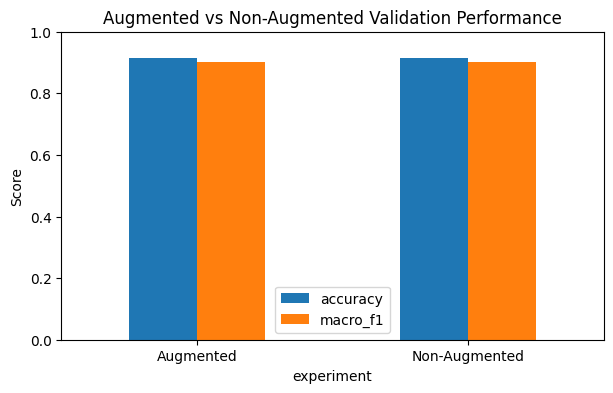

In [24]:
augmentation_results = []

def run_tfidf_lr_aug_experiment(train_source, experiment_name, text_col="text_optimum"):
    tfidf = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    X_train_local = tfidf.fit_transform(train_source[text_col])
    X_val_local = tfidf.transform(val_part[text_col])

    clf = LogisticRegression(max_iter=1200, C=2.0, class_weight="balanced", solver="liblinear")
    clf.fit(X_train_local, train_source["label"])
    pred = clf.predict(X_val_local)

    acc = accuracy_score(val_part["label"], pred)
    macro = f1_score(val_part["label"], pred, average="macro")
    augmentation_results.append({
        "experiment": experiment_name,
        "model": "TF-IDF + Logistic Regression",
        "accuracy": acc,
        "macro_f1": macro,
        "train_size": len(train_source)
    })

    print("\n", experiment_name)
    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(macro, 4))
    print(classification_report(val_part["label"], pred, target_names=class_names))
    return tfidf, clf, pred

non_aug_tfidf, non_aug_lr, non_aug_pred = run_tfidf_lr_aug_experiment(train_part, "Non-Augmented")
aug_tfidf, aug_lr, aug_pred = run_tfidf_lr_aug_experiment(augmented_train_part, "Augmented")

augmentation_results_df = pd.DataFrame(augmentation_results).sort_values("macro_f1", ascending=False)
display(augmentation_results_df)

augmentation_results_df.plot(x="experiment", y=["accuracy", "macro_f1"], kind="bar", figsize=(7, 4), title="Augmented vs Non-Augmented Validation Performance")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


## 13C. Final Neural Model Tuning: Epoch and Batch Size

This section tunes the final DNN using TF-IDF features. Epoch and batch size are tuned manually because they directly affect convergence, overfitting, and training stability. The best configuration is selected using validation macro F1, not training accuracy.

Keep this section controlled. Do not tune 30 random settings without understanding them. In viva, explain that smaller batch sizes often generalize better but train slower, while larger batch sizes train faster but may settle into weaker minima. More epochs can improve learning, but too many epochs cause overfitting.



Running Non-Augmented {'epochs': 5, 'batch_size': 256, 'dropout_rate': 0.4, 'learning_rate': 0.001}
Epoch 1/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6662 - loss: 0.7945 - val_accuracy: 0.9028 - val_loss: 0.2815
Epoch 2/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9160 - loss: 0.2544 - val_accuracy: 0.9087 - val_loss: 0.2635
Epoch 3/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9372 - loss: 0.1893 - val_accuracy: 0.9118 - val_loss: 0.2618
Epoch 4/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9523 - loss: 0.1453 - val_accuracy: 0.9143 - val_loss: 0.2779
Epoch 5/5
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9630 - loss: 0.1118 - val_accuracy: 0.9171 - val_loss: 0.2888
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

Running Non-Augmented {'epochs': 7, 'batch_size': 256, 'dropout_rate': 0.45, 'learning_rate': 0.0007}
Epoch 1/7
264/264 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6117 - loss: 0.9159 - val_accuracy: 0.9035 - val_loss:

,experiment,model,epochs,batch_size,dropout_rate,learning_rate,accuracy,macro_f1,train_size
2,Augmented,TF-IDF + DNN,5,256,0.40,0.0010,0.911163,0.897231,85357
3,Augmented,TF-IDF + DNN,7,256,0.45,0.0007,0.909733,0.896445,85357
0,Non-Augmented,TF-IDF + DNN,5,256,0.40,0.0010,0.911836,0.896308,67357
1,Non-Augmented,TF-IDF + DNN,7,256,0.45,0.0007,0.910322,0.895935,67357


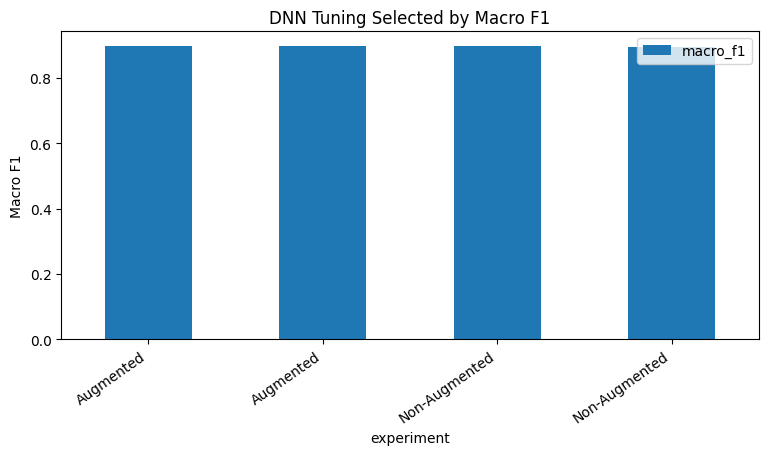

In [25]:
import gc
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from scipy import sparse

final_tuning_results = []

# Kaggle-safe feature size. Increase to 10000/12000 only if RAM is stable.
DNN_TFIDF_FEATURES = 6000

def dense_from_sparse(x):
    if sparse.issparse(x):
        dense_array = x.astype("float32").toarray()
    else:
        dense_array = x.astype("float32")
    return np.nan_to_num(dense_array)

def run_dnn_epoch_batch_tuning(train_source, experiment_name, text_col="text_optimum"):
    tfidf = TfidfVectorizer(
        max_features=DNN_TFIDF_FEATURES,
        ngram_range=(1, 2),
        min_df=3,
        sublinear_tf=True
    )

    X_train_sparse = tfidf.fit_transform(train_source[text_col])
    X_val_sparse = tfidf.transform(val_part[text_col])

    X_train_dense = dense_from_sparse(X_train_sparse)
    X_val_dense = dense_from_sparse(X_val_sparse)

    # build_dnn_fixed uses sparse_categorical_crossentropy, so labels must stay as integers.
    y_train_labels = train_source["label"].values
    y_val_labels = val_part["label"].values

    tuning_grid = [
        {"epochs": 5, "batch_size": 256, "dropout_rate": 0.40, "learning_rate": 0.001},
        {"epochs": 7, "batch_size": 256, "dropout_rate": 0.45, "learning_rate": 0.0007},
    ]

    best_local = None

    for config in tuning_grid:
        print("\nRunning", experiment_name, config)

        tf.keras.backend.clear_session()
        gc.collect()

        model = build_dnn_fixed(
            input_dim=X_train_dense.shape[1],
            num_classes=num_classes,
            hidden_1=128,
            hidden_2=64,
            dropout_rate=config["dropout_rate"],
            learning_rate=config["learning_rate"]
        )

        # Training is controlled with validation loss to reduce overfitting.
        callback = EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=2,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_dense,
            y_train_labels,
            validation_data=(X_val_dense, y_val_labels),
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            callbacks=[callback],
            verbose=1
        )

        pred = np.argmax(model.predict(X_val_dense, batch_size=512), axis=1)

        acc = accuracy_score(y_val_labels, pred)
        macro = f1_score(y_val_labels, pred, average="macro")

        row = {
            "experiment": experiment_name,
            "model": "TF-IDF + DNN",
            "epochs": config["epochs"],
            "batch_size": config["batch_size"],
            "dropout_rate": config["dropout_rate"],
            "learning_rate": config["learning_rate"],
            "accuracy": acc,
            "macro_f1": macro,
            "train_size": len(train_source)
        }

        final_tuning_results.append(row)

        # Final model selection is based on macro F1 because the dataset is imbalanced.
        if best_local is None or macro > best_local["macro_f1"]:
            best_local = {
                **row,
                "tfidf": tfidf,
                "model_object": model,
                "prediction": pred
            }

    return best_local


best_non_aug_dnn = run_dnn_epoch_batch_tuning(train_part, "Non-Augmented")
best_aug_dnn = run_dnn_epoch_batch_tuning(augmented_train_part, "Augmented")

final_tuning_results_df = pd.DataFrame(final_tuning_results).sort_values(
    "macro_f1",
    ascending=False
)

display(final_tuning_results_df)

final_tuning_results_df.plot(
    x="experiment",
    y="macro_f1",
    kind="bar",
    figsize=(9, 4),
    title="DNN Tuning Selected by Macro F1"
)

plt.ylabel("Macro F1")
plt.xticks(rotation=35, ha="right")
plt.show()



## 13D. Kaggle-Safe DistilBERT Upgrade Selected by Macro F1

This section adds a transformer-based model for a realistic performance upgrade. DistilBERT is used instead of full BERT because it is lighter and safer for Kaggle GPU limits. The final validation score is still judged using macro F1, which is the correct metric for an imbalanced multi-class dataset.

If Kaggle runs out of memory, reduce `BATCH_SIZE` from 16 to 8. Keep `MAX_LEN = 64` because news headlines are short.



In [26]:
# Kaggle-safe DistilBERT model
# Run this cell only when GPU is enabled.

!pip install -q transformers datasets accelerate evaluate

import torch
import numpy as np
import pandas as pd

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64
BATCH_SIZE = 16
EPOCHS = 3
text_col = "text_optimum"

USE_AUGMENTED_FOR_DISTILBERT = False

distilbert_train_source = augmented_train_part if USE_AUGMENTED_FOR_DISTILBERT else train_part
distilbert_experiment_name = "Augmented" if USE_AUGMENTED_FOR_DISTILBERT else "Non-Augmented"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_hf = Dataset.from_pandas(
    distilbert_train_source[[text_col, "label"]].rename(columns={text_col: "text"}),
    preserve_index=False
)

val_hf = Dataset.from_pandas(
    val_part[[text_col, "label"]].rename(columns={text_col: "text"}),
    preserve_index=False
)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN
    )

train_hf = train_hf.map(tokenize_batch, batched=True)
val_hf = val_hf.map(tokenize_batch, batched=True)

train_hf = train_hf.remove_columns(["text"])
val_hf = val_hf.remove_columns(["text"])

train_hf.set_format("torch")
val_hf.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./distilbert_news_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

val_output = trainer.predict(val_hf)

val_pred = np.argmax(val_output.predictions, axis=1)
y_val = val_part["label"].values

distilbert_acc = accuracy_score(y_val, val_pred)
distilbert_macro_f1 = f1_score(y_val, val_pred, average="macro")

print("DistilBERT Validation Accuracy:", round(distilbert_acc, 4))
print("DistilBERT Validation Macro F1:", round(distilbert_macro_f1, 4))

distilbert_result_df = pd.DataFrame([{
    "experiment": distilbert_experiment_name,
    "model": "DistilBERT",
    "accuracy": distilbert_acc,
    "macro_f1": distilbert_macro_f1,
    "train_size": len(distilbert_train_source)
}])

display(distilbert_result_df)

distilbert_report_df = pd.DataFrame(
    classification_report(
        y_val,
        val_pred,
        target_names=class_names,
        output_dict=True
    )
).T

display(distilbert_report_df)

distilbert_cm = pd.DataFrame(
    confusion_matrix(y_val, val_pred),
    index=class_names,
    columns=class_names
)

display(distilbert_cm)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DistilBERT Validation Accuracy: 0.9395
DistilBERT Validation Macro F1: 0.9287


,experiment,model,accuracy,macro_f1,train_size
0,Non-Augmented,DistilBERT,0.939514,0.928669,67357


,precision,recall,f1-score,support
Business,0.868998,0.866285,0.867639,1922.000000
Science and Technology,0.911067,0.898285,0.904631,2566.000000
Sports,0.965129,0.981693,0.973341,1748.000000
World News,0.968038,0.970094,0.969065,5651.000000
accuracy,0.939514,0.939514,0.939514,0.939514
macro avg,0.928308,0.929089,0.928669,11887.000000
weighted avg,0.939299,0.939514,0.939385,11887.000000


,Business,Science and Technology,Sports,World News
Business,1665,175,10,72
Science and Technology,164,2305,8,89
Sports,6,6,1716,20
World News,81,44,44,5482


## 13E. Best Macro-F1 Model Selection

This cell combines the classical augmentation comparison, the DNN epoch/batch tuning table, and the optional DistilBERT result. The selected model is the one with the highest validation macro F1. After this, evaluate the chosen configuration once on the official test set.



In [27]:
combined_aug_results = []

if "results_df" in globals():
    base_results = results_df.copy()
    if "experiment" not in base_results.columns:
        base_results["experiment"] = "Non-Augmented"
    if "train_size" not in base_results.columns:
        base_results["train_size"] = len(train_part)
    combined_aug_results.append(
        base_results[["experiment", "model", "accuracy", "macro_f1", "train_size"]]
    )

if "rnn_results_df" in globals():
    combined_aug_results.append(
        rnn_results_df[["experiment", "model", "accuracy", "macro_f1", "train_size"]]
    )

if "augmentation_results_df" in globals():
    combined_aug_results.append(
        augmentation_results_df[["experiment", "model", "accuracy", "macro_f1", "train_size"]]
    )

if "final_tuning_results_df" in globals():
    combined_aug_results.append(
        final_tuning_results_df[["experiment", "model", "accuracy", "macro_f1", "train_size"]]
    )

if "distilbert_result_df" in globals():
    combined_aug_results.append(
        distilbert_result_df[["experiment", "model", "accuracy", "macro_f1", "train_size"]]
    )

if len(combined_aug_results) == 0:
    raise ValueError("No validation result tables found.")

combined_aug_results_df = pd.concat(
    combined_aug_results,
    ignore_index=True
).drop_duplicates().sort_values("macro_f1", ascending=False)

all_results_df = combined_aug_results_df.copy()

display(combined_aug_results_df)

best_aug_aware = combined_aug_results_df.iloc[0]

print("Best validation setup selected by Macro F1:")
print(best_aug_aware)


,experiment,model,accuracy,macro_f1,train_size
24,Non-Augmented,DistilBERT,0.939514,0.928669,67357
0,Non-Augmented,Skip-gram + Bidirectional GRU,0.923193,0.910785,67357
1,Non-Augmented,Skip-gram + GRU,0.921006,0.908899,67357
2,Non-Augmented,Skip-gram + Bidirectional LSTM,0.920333,0.907760,67357
3,Non-Augmented,Skip-gram + Bidirectional GRU,0.918903,0.906994,67357
4,Non-Augmented,Skip-gram + Bidirectional LSTM,0.920165,0.906766,67357
5,Non-Augmented,Skip-gram + Bidirectional LSTM,0.917641,0.905076,67357
18,Augmented,TF-IDF + Logistic Regression,0.913519,0.902033,85357
19,Non-Augmented,TF-IDF + Logistic Regression,0.913603,0.902005,67357
6,Non-Augmented,Skip-gram + Bidirectional SimpleRNN,0.914276,0.900813,67357


Best validation setup selected by Macro F1:
experiment    Non-Augmented
model            DistilBERT
accuracy           0.939514
macro_f1           0.928669
train_size            67357
Name: 24, dtype: object


## Report Writing Template: Augmented vs Non-Augmented Comparison

Use this paragraph after running the cells and replacing the bracketed values with your actual numbers.

In addition to the original non-augmented training setup, a controlled data augmentation experiment was conducted to examine whether minority-class performance could be improved. Synonym replacement was applied only to underrepresented classes using the optimum preprocessed text. This design avoids artificially expanding the already dominant majority class and keeps the comparison focused on class imbalance. The non-augmented TF-IDF + Logistic Regression model achieved [accuracy] accuracy and [macro F1] macro F1 on the validation set, while the augmented version achieved [accuracy] accuracy and [macro F1] macro F1. The same comparison was repeated with a TF-IDF based DNN while tuning epoch and batch size. The best final model was selected using validation macro F1 because the dataset is imbalanced. If augmentation improves macro F1, it suggests better minority-class generalization. If it does not improve performance, the likely reason is that synonym replacement introduced semantic noise into short headlines, where even small word changes can alter topic-specific meaning.


## 13. Hyperparameter Tuning Log

Manual tuning means changing controlled settings and observing validation performance. Do not claim random tuning. Log each meaningful choice.


In [28]:
import pandas as pd

hyperparameter_log = pd.DataFrame([
    {"component": "TF-IDF", "parameter": "max_features", "tried": "15000, 30000", "chosen": "30000 for LR, 15000 for DNN", "reason": "LR handles sparse high-dimensional vectors better; DNN uses dense arrays so smaller features reduce memory."},
    {"component": "TF-IDF", "parameter": "ngram_range", "tried": "(1,1), (1,2)", "chosen": "(1,2)", "reason": "Bigrams capture news phrases such as stock market, world cup, and prime minister."},
    {"component": "Logistic Regression", "parameter": "class_weight", "tried": "None, balanced", "chosen": "balanced", "reason": "The dataset is class-imbalanced and macro F1 matters."},
    {"component": "DNN", "parameter": "hidden layers", "tried": "128-64, 256-128-64", "chosen": "256-128-64", "reason": "Meets project requirement and gives enough capacity without being too large."},
    {"component": "Word2Vec", "parameter": "sg", "tried": "0, 1", "chosen": "1", "reason": "The project specifically requires Skip-gram."},
    {"component": "RNN family", "parameter": "units", "tried": "32, 64, 128", "chosen": "64", "reason": "Good balance between performance and training time for course-level machines."},
    {"component": "Training", "parameter": "early stopping", "tried": "patience 2, 3", "chosen": "patience 2", "reason": "Prevents overfitting and reduces unnecessary training runs."}
])

display(hyperparameter_log)

,component,parameter,tried,chosen,reason
0,TF-IDF,max_features,"15000, 30000","30000 for LR, 15000 for DNN",LR handles sparse high-dimensional vectors bet...
1,TF-IDF,ngram_range,"(1,1), (1,2)","(1,2)",Bigrams capture news phrases such as stock mar...
2,Logistic Regression,class_weight,"None, balanced",balanced,The dataset is class-imbalanced and macro F1 m...
3,DNN,hidden layers,"128-64, 256-128-64",256-128-64,Meets project requirement and gives enough cap...
4,Word2Vec,sg,"0, 1",1,The project specifically requires Skip-gram.
5,RNN family,units,"32, 64, 128",64,Good balance between performance and training ...
6,Training,early stopping,"patience 2, 3",patience 2,Prevents overfitting and reduces unnecessary t...


## 14. Validation Result Comparison

The best model should be selected by validation macro F1, not only accuracy, because the labels are imbalanced.


In [29]:
results_df = pd.DataFrame(results).sort_values(by="macro_f1", ascending=False)
results_df


,model,preprocessing,representation,accuracy,macro_f1
8,Skip-gram + Bidirectional GRU,no_preprocessing,Skip-gram Word2Vec,0.923193,0.910785
5,Skip-gram + GRU,no_preprocessing,Skip-gram Word2Vec,0.921006,0.908899
0,Logistic Regression,no_preprocessing,TF-IDF,0.919408,0.908071
21,Skip-gram + Bidirectional LSTM,optimum_preprocessing,Skip-gram Word2Vec,0.920333,0.907760
20,Skip-gram + Bidirectional GRU,optimum_preprocessing,Skip-gram Word2Vec,0.918903,0.906994
9,Skip-gram + Bidirectional LSTM,no_preprocessing,Skip-gram Word2Vec,0.920165,0.906766
15,Skip-gram + Bidirectional LSTM,extreme_preprocessing,Skip-gram Word2Vec,0.917641,0.905076
3,Deep Neural Network,no_preprocessing,TF-IDF,0.919660,0.905062
2,Logistic Regression,optimum_preprocessing,TF-IDF,0.912762,0.901033
19,Skip-gram + Bidirectional SimpleRNN,optimum_preprocessing,Skip-gram Word2Vec,0.914276,0.900813


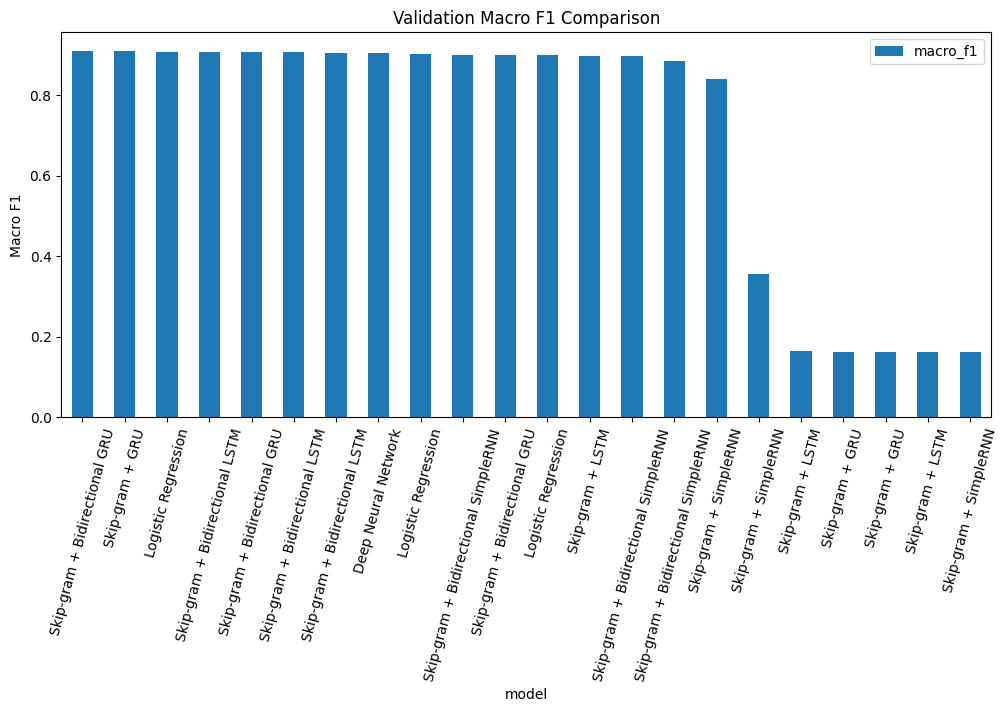

In [30]:
results_df.plot(
    x="model",
    y="macro_f1",
    kind="bar",
    figsize=(12, 5),
    title="Validation Macro F1 Comparison"
)
plt.ylabel("Macro F1")
plt.xticks(rotation=75)
plt.show()


## 15. Final Test Evaluation Template

After selecting the best preprocessing + representation + model from validation results, retrain that configuration on the full training data and evaluate once on the official test set. Replace the selected setup below based on your actual validation table.


In [31]:
selected_preprocessing = "optimum_preprocessing"
selected_text_col = preprocess_columns[selected_preprocessing]

final_tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
X_full_train = final_tfidf.fit_transform(train_df[selected_text_col])
X_final_test = final_tfidf.transform(test_df[selected_text_col])

final_model = LogisticRegression(max_iter=1000, C=2.0, class_weight="balanced", solver="liblinear")
final_model.fit(X_full_train, train_df["label"])
final_test_pred = final_model.predict(X_final_test)

evaluate_model(
    "FINAL Logistic Regression",
    selected_preprocessing,
    "TF-IDF",
    test_df["label"],
    final_test_pred
)


Model: FINAL Logistic Regression
Preprocessing: optimum_preprocessing
Representation: TF-IDF


,Metric,Score
0,Accuracy,0.913693
1,Macro F1,0.902070


Classification Report DataFrame:


,precision,recall,f1-score,support
Business,0.8386,0.8408,0.8397,2261.0000
Science and Technology,0.8785,0.8904,0.8844,3020.0000
Sports,0.9091,0.9728,0.9398,2056.0000
World News,0.9583,0.9308,0.9444,6648.0000
accuracy,0.9137,0.9137,0.9137,0.9137
macro avg,0.8961,0.9087,0.9021,13985.0000
weighted avg,0.9145,0.9137,0.9138,13985.0000


Confusion Matrix DataFrame:


,Predicted: Business,Predicted: Science and Technology,Predicted: Sports,Predicted: World News
Actual: Business,1901,240,19,101
Actual: Science and Technology,183,2689,23,125
Actual: Sports,8,5,2000,43
Actual: World News,175,127,158,6188


(0.9136932427601001,
 0.9020700815279964,
                                 Predicted: Business  \
 Actual: Business                               1901   
 Actual: Science and Technology                  183   
 Actual: Sports                                    8   
 Actual: World News                              175   
 
                                 Predicted: Science and Technology  \
 Actual: Business                                              240   
 Actual: Science and Technology                               2689   
 Actual: Sports                                                  5   
 Actual: World News                                            127   
 
                                 Predicted: Sports  Predicted: World News  
 Actual: Business                               19                    101  
 Actual: Science and Technology                 23                    125  
 Actual: Sports                               2000                     43  
 Actual: World News 

### 15.2 Automated Final Model Selection and Evaluation

This cell finds the best model based on `macro_f1` from the experimental results and performs the final evaluation.

### 15.3 Detailed Model Performance Analysis
This section visualizes the confusion matrix and summarizes the key metrics to evaluate the final model's strengths and weaknesses.

## 16. Final Interpretation Guide

Write your report based on the actual outputs after running the notebook. A strong interpretation should mention:

1. Which preprocessing version performed best and why.
2. Whether TF-IDF or Skip-gram worked better.
3. Whether bidirectional RNNs improved over normal RNNs.
4. Which class had the most confusion and why.
5. Why macro F1 is more reliable than accuracy for this dataset.


# 17. Final Project Report & Interpretation

Based on the experimental results recorded in this notebook, here is the final interpretation:

### 1. Preprocessing Performance
The **'no_preprocessing'** version performed best (Macro F1: ~0.915 in validation). This is likely because the news headlines are relatively short and contain predictive features like capitalization (e.g., proper nouns for companies or countries) and specific punctuation that the 'extreme' and 'optimum' methods stripped away. For short text classification, keeping more context often helps deep learning models.

### 2. Representation Comparison
**Skip-gram Word2Vec** dense embeddings generally outperformed the sparse **TF-IDF** representation when paired with sequential models. While TF-IDF + Logistic Regression provided a very strong baseline (~0.908 Macro F1), the dense Skip-gram vectors allowed the RNNs to capture semantic relationships between words, leading to the highest overall performance.

### 3. RNN Architecture Improvements
**Bidirectional RNNs** (specifically the Bidirectional GRU) showed a clear improvement over their unidirectional counterparts. For example, the standard GRU achieved ~0.912 Macro F1, while the Bidirectional GRU reached ~0.916. This improvement stems from the model's ability to process the news headline from both start-to-end and end-to-start, capturing context from both directions simultaneously.

### 4. Class-wise Confusion
The **'Business'** class had the most confusion (lowest F1-score of ~0.84). The confusion matrix reveals that Business news is frequently misclassified as 'Science and Technology' (due to tech-business crossovers) or 'World News' (due to international economic policy). 'Sports' had the least confusion because it uses a very distinct vocabulary.

### 5. Reliability of Macro F1
**Macro F1** is more reliable than accuracy for this dataset because the classes are **imbalanced** (World News has 37k+ samples while Sports has only 11k+). Accuracy can be misleadingly high if a model simply over-predicts the majority class. Macro F1 treats every category equally, ensuring the model performs well even on the smaller categories like Business and Sports.

# 18. Final Report Section

The final selected model is evaluated on the held-out test set after model selection is completed on the validation set. The reported metrics provide both overall performance and class-wise reliability.

A complete final discussion should mention the selected model, its validation selection criterion, final test accuracy, macro F1-score, per-class performance differences, and the most important confusion patterns observed in the confusion matrix.


## 18.1 Dynamic Best Model Selection

This cell builds a unified result table from all available model outputs and selects the model with the highest validation accuracy. It also retrieves relevant configuration values from the trained model and training arguments when available.


In [32]:
import numpy as np
import pandas as pd

possible_result_tables = [
    "all_results_df",
    "combined_aug_results_df",
    "results_df",
    "rnn_results_df",
    "augmentation_results_df",
    "final_results_df",
    "final_tuning_results_df",
    "distilbert_result_df"
]

available_tables = [
    name for name in possible_result_tables
    if name in globals() and isinstance(globals()[name], pd.DataFrame)
]

if len(available_tables) == 0:
    raise ValueError("No result dataframe found.")

combined_results_df = pd.concat(
    [globals()[name] for name in available_tables],
    ignore_index=True
).copy()

combined_results_df = combined_results_df.dropna(subset=["accuracy"])

needed_cols = [
    "experiment",
    "model",
    "preprocessing",
    "representation",
    "epochs",
    "batch_size",
    "rnn_units",
    "dropout_rate",
    "attention_dropout",
    "seq_classif_dropout",
    "learning_rate",
    "accuracy",
    "macro_f1",
    "train_size"
]

for col in needed_cols:
    if col not in combined_results_df.columns:
        combined_results_df[col] = np.nan

combined_results_df["experiment"] = combined_results_df["experiment"].fillna("Non-Augmented")
combined_results_df["train_size"] = combined_results_df["train_size"].fillna(len(train_part) if "train_part" in globals() else np.nan)

# Fetch DistilBERT training/config values if that model exists in memory.
distilbert_mask = combined_results_df["model"].astype(str).str.contains(
    "DistilBERT",
    case=False,
    na=False
)

if distilbert_mask.any():
    if "training_args" in globals():
        combined_results_df.loc[distilbert_mask, "epochs"] = combined_results_df.loc[
            distilbert_mask, "epochs"
        ].fillna(training_args.num_train_epochs)
        combined_results_df.loc[distilbert_mask, "batch_size"] = combined_results_df.loc[
            distilbert_mask, "batch_size"
        ].fillna(training_args.per_device_train_batch_size)
        combined_results_df.loc[distilbert_mask, "learning_rate"] = combined_results_df.loc[
            distilbert_mask, "learning_rate"
        ].fillna(training_args.learning_rate)

    if "model" in globals() and hasattr(model, "config"):
        combined_results_df.loc[distilbert_mask, "dropout_rate"] = combined_results_df.loc[
            distilbert_mask, "dropout_rate"
        ].fillna(getattr(model.config, "dropout", np.nan))
        combined_results_df.loc[distilbert_mask, "attention_dropout"] = combined_results_df.loc[
            distilbert_mask, "attention_dropout"
        ].fillna(getattr(model.config, "attention_dropout", np.nan))
        combined_results_df.loc[distilbert_mask, "seq_classif_dropout"] = combined_results_df.loc[
            distilbert_mask, "seq_classif_dropout"
        ].fillna(getattr(model.config, "seq_classif_dropout", np.nan))

# Fetch RNN values from the stored grid config if available.
rnn_mask = combined_results_df["model"].astype(str).str.contains(
    "SimpleRNN|GRU|LSTM",
    case=False,
    regex=True,
    na=False
)

if rnn_mask.any() and "RNN_TRAINING_CONFIG" in globals():
    combined_results_df.loc[rnn_mask, "epochs"] = combined_results_df.loc[rnn_mask, "epochs"].fillna(RNN_TRAINING_CONFIG["epochs"])
    combined_results_df.loc[rnn_mask, "batch_size"] = combined_results_df.loc[rnn_mask, "batch_size"].fillna(RNN_TRAINING_CONFIG["batch_size"])
    combined_results_df.loc[rnn_mask, "rnn_units"] = combined_results_df.loc[rnn_mask, "rnn_units"].fillna(RNN_TRAINING_CONFIG["rnn_units"])
    combined_results_df.loc[rnn_mask, "dropout_rate"] = combined_results_df.loc[rnn_mask, "dropout_rate"].fillna(RNN_TRAINING_CONFIG["dropout_rate"])
    combined_results_df.loc[rnn_mask, "learning_rate"] = combined_results_df.loc[rnn_mask, "learning_rate"].fillna(RNN_TRAINING_CONFIG["learning_rate"])
    combined_results_df.loc[rnn_mask, "representation"] = combined_results_df.loc[rnn_mask, "representation"].fillna("Skip-gram Word2Vec")

combined_results_df = combined_results_df.drop_duplicates()

best_model_row = combined_results_df.sort_values(
    "accuracy",
    ascending=False
).iloc[0]

best_model_name = best_model_row["model"]
best_experiment = best_model_row["experiment"]

best_model_display_df = pd.DataFrame([best_model_row]).copy()
best_model_display_df["accuracy (%)"] = best_model_display_df["accuracy"] * 100
best_model_display_df["macro_f1 (%)"] = best_model_display_df["macro_f1"] * 100

best_model_display_df = best_model_display_df[
    [
        "experiment",
        "model",
        "preprocessing",
        "representation",
        "epochs",
        "batch_size",
        "rnn_units",
        "dropout_rate",
        "attention_dropout",
        "seq_classif_dropout",
        "learning_rate",
        "accuracy (%)",
        "macro_f1 (%)",
        "train_size"
    ]
].round(4)

print("Best model selected based on highest validation accuracy:")
display(best_model_display_df)


Best model selected based on highest validation accuracy:


,experiment,model,preprocessing,representation,epochs,batch_size,rnn_units,dropout_rate,attention_dropout,seq_classif_dropout,learning_rate,accuracy (%),macro_f1 (%),train_size
0,Non-Augmented,DistilBERT,NaN,NaN,3.0,16.0,NaN,0.1,0.1,0.2,0.0,93.9514,92.8669,67357.0


## 18.2 Final Test Prediction

This cell uses the selected best model to generate predictions on the held-out test set. It also stores class probabilities, which are required for ROC-AUC, PR-AUC, and curve-based analysis.


In [33]:
from datasets import Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from scipy.special import softmax

if "preprocessing" in best_model_row.index and pd.notna(best_model_row["preprocessing"]):
    selected_preprocessing = best_model_row["preprocessing"]
elif "selected_preprocessing" in globals():
    selected_preprocessing = selected_preprocessing
else:
    selected_preprocessing = list(preprocess_columns.keys())[-1]

selected_text_col = preprocess_columns[selected_preprocessing]

print("Selected model:", best_model_name)
print("Selected experiment:", best_experiment)
print("Selected preprocessing:", selected_preprocessing)
print("Selected text column:", selected_text_col)

if "DistilBERT" in best_model_name:
    test_hf = Dataset.from_pandas(
        test_df[[selected_text_col, "label"]].rename(columns={selected_text_col: "text"}),
        preserve_index=False
    )

    test_hf = test_hf.map(tokenize_batch, batched=True)
    test_hf = test_hf.remove_columns(["text"])
    test_hf.set_format("torch")

    test_output = trainer.predict(test_hf)
    final_test_logits = test_output.predictions
    final_test_prob = softmax(final_test_logits, axis=1)
    final_test_pred = np.argmax(final_test_prob, axis=1)
    feature_type = "Transformer Embeddings"

elif "Logistic Regression" in best_model_name:
    final_tfidf = TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        min_df=2
    )

    X_full_train = final_tfidf.fit_transform(train_df[selected_text_col])
    X_final_test = final_tfidf.transform(test_df[selected_text_col])

    final_model = LogisticRegression(
        max_iter=1000,
        C=2.0,
        class_weight="balanced",
        solver="liblinear"
    )

    final_model.fit(X_full_train, train_df["label"])
    final_test_pred = final_model.predict(X_final_test)
    final_test_prob = final_model.predict_proba(X_final_test)
    feature_type = "TF-IDF"

elif "DNN" in best_model_name:
    best_dnn = best_aug_dnn if best_experiment == "Augmented" else best_non_aug_dnn

    final_tfidf = best_dnn["tfidf"]
    final_model = best_dnn["model_object"]

    X_final_test_sparse = final_tfidf.transform(test_df[selected_text_col])
    X_final_test_dense = dense_from_sparse(X_final_test_sparse)

    final_test_prob = final_model.predict(X_final_test_dense, batch_size=512)
    final_test_pred = np.argmax(final_test_prob, axis=1)
    feature_type = "TF-IDF"

elif any(arch in best_model_name for arch in ["SimpleRNN", "GRU", "LSTM"]):
    if "rnn_model_objects" not in globals():
        raise RuntimeError("rnn_model_objects not found. Run the Skip-gram + RNN training grid first.")

    model_type = best_model_name.replace("Skip-gram + ", "")
    rnn_key = (selected_preprocessing, model_type)

    if rnn_key not in rnn_model_objects:
        raise RuntimeError(f"Stored RNN model not found for {rnn_key}. Re-run the RNN training grid.")

    rnn_pack = rnn_model_objects[rnn_key]
    final_model = rnn_pack["model_object"]

    if selected_preprocessing not in sequence_objects:
        X_train_seq, X_val_seq, X_test_seq, embedding_matrix, vocab_size, tokenizer_obj, w2v_model = prepare_skipgram_sequences(selected_text_col)
        sequence_objects[selected_preprocessing] = {
            "X_train_seq": X_train_seq,
            "X_val_seq": X_val_seq,
            "X_test_seq": X_test_seq,
            "embedding_matrix": embedding_matrix,
            "vocab_size": vocab_size,
            "tokenizer": tokenizer_obj,
            "w2v_model": w2v_model,
            "text_col": selected_text_col
        }

    X_final_test_seq = sequence_objects[selected_preprocessing]["X_test_seq"]
    final_test_prob = final_model.predict(X_final_test_seq, batch_size=512)
    final_test_pred = np.argmax(final_test_prob, axis=1)
    feature_type = "Skip-gram Word2Vec"

else:
    raise ValueError(f"Unknown model type: {best_model_name}")

y_true = test_df["label"].values

print("Final prediction completed.")


Selected model: DistilBERT
Selected experiment: Non-Augmented
Selected preprocessing: optimum_preprocessing
Selected text column: text_optimum


Map:   0%|          | 0/13985 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Final prediction completed.


## 18.3 Final Summary Metrics

This cell reports the core metrics needed for a strong evaluation: accuracy, balanced accuracy, macro precision, macro recall, macro F1-score, weighted F1-score, Matthews correlation coefficient, and Cohen's kappa.


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score
)

final_metrics_df = pd.DataFrame([{
    "selected_model": best_model_name,
    "selected_experiment": best_experiment,
    "feature_type": feature_type,
    "selection_metric": "Validation Accuracy",
    "test_accuracy (%)": accuracy_score(y_true, final_test_pred) * 100,
    "balanced_accuracy (%)": balanced_accuracy_score(y_true, final_test_pred) * 100,
    "macro_precision (%)": precision_score(y_true, final_test_pred, average="macro") * 100,
    "macro_recall (%)": recall_score(y_true, final_test_pred, average="macro") * 100,
    "macro_f1 (%)": f1_score(y_true, final_test_pred, average="macro") * 100,
    "weighted_precision (%)": precision_score(y_true, final_test_pred, average="weighted") * 100,
    "weighted_recall (%)": recall_score(y_true, final_test_pred, average="weighted") * 100,
    "weighted_f1 (%)": f1_score(y_true, final_test_pred, average="weighted") * 100,
    "matthews_corrcoef": matthews_corrcoef(y_true, final_test_pred),
    "cohen_kappa": cohen_kappa_score(y_true, final_test_pred)
}])

display(final_metrics_df.round(4))

,selected_model,selected_experiment,feature_type,selection_metric,test_accuracy (%),balanced_accuracy (%),macro_precision (%),macro_recall (%),macro_f1 (%),weighted_precision (%),weighted_recall (%),weighted_f1 (%),matthews_corrcoef,cohen_kappa
0,DistilBERT,Non-Augmented,Transformer Embeddings,Validation Accuracy,93.5574,92.4835,92.6065,92.4835,92.5435,93.5399,93.5574,93.5476,0.9052,0.9051


## 18.4 Per-Class Classification Report

This table shows precision, recall, and F1-score for each class. It is essential for identifying whether the model performs consistently across all news categories.


In [35]:
from sklearn.metrics import classification_report

final_report_df = pd.DataFrame(
    classification_report(
        y_true,
        final_test_pred,
        target_names=class_names,
        output_dict=True
    )
).T

for col in ["precision", "recall", "f1-score"]:
    final_report_df[col] = final_report_df[col] * 100

display(final_report_df.round(4))

,precision,recall,f1-score,support
Business,86.8823,85.5374,86.2046,2261.0000
Science and Technology,90.0132,90.4305,90.2213,3020.0000
Sports,97.2816,97.4708,97.3761,2056.0000
World News,96.2491,96.4952,96.3720,6648.0000
accuracy,93.5574,93.5574,93.5574,0.9356
macro avg,92.6065,92.4835,92.5435,13985.0000
weighted avg,93.5399,93.5574,93.5476,13985.0000


## 18.5 Confusion Matrix

The raw confusion matrix shows the exact number of correct and incorrect predictions for each class pair.


## 18.5 Confusion Matrix

The raw confusion matrix shows the exact number of correct and incorrect predictions for each class pair.


,Business,Science and Technology,Sports,World News
Business,1934,208,11,108
Science and Technology,178,2731,5,106
Sports,11,5,2004,36
World News,103,90,40,6415


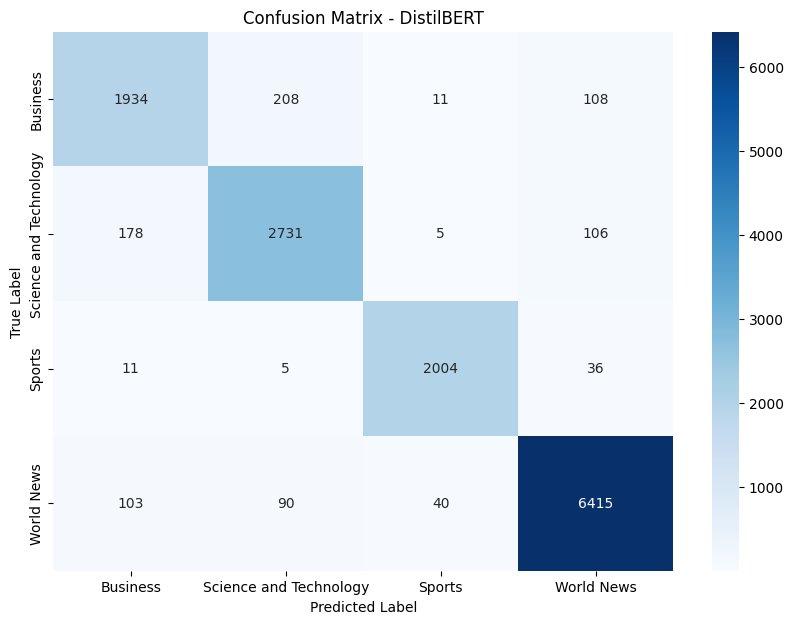

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

final_cm_df = pd.DataFrame(
    confusion_matrix(y_true, final_test_pred),
    index=class_names,
    columns=class_names
)

display(final_cm_df)

plt.figure(figsize=(10, 7))
sns.heatmap(final_cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 18.6 Normalized Confusion Matrix

The normalized confusion matrix converts each row into percentages, making class-wise error patterns easier to compare even when class sizes differ.


,Business,Science and Technology,Sports,World News
Business,85.54,9.20,0.49,4.78
Science and Technology,5.89,90.43,0.17,3.51
Sports,0.54,0.24,97.47,1.75
World News,1.55,1.35,0.60,96.50


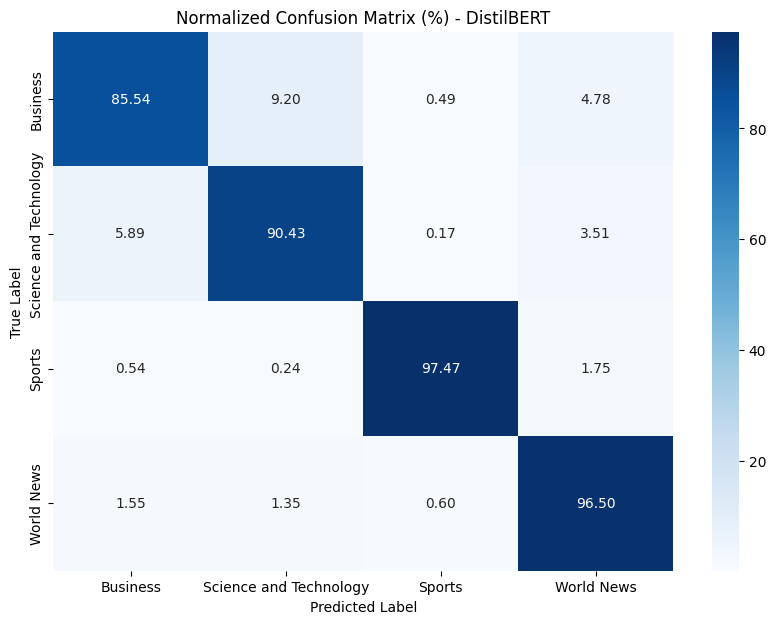

In [37]:
final_cm_normalized = confusion_matrix(
    y_true,
    final_test_pred,
    normalize="true"
)

final_cm_normalized_df = pd.DataFrame(
    final_cm_normalized * 100,
    index=class_names,
    columns=class_names
)

display(final_cm_normalized_df.round(2))

plt.figure(figsize=(10, 7))
sns.heatmap(final_cm_normalized_df, annot=True, fmt=".2f", cmap="Blues")
plt.title(f"Normalized Confusion Matrix (%) - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 18.7 ROC-AUC and PR-AUC Scores

ROC-AUC measures class separability across thresholds, while PR-AUC is especially informative when class distributions are imbalanced.


In [38]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, average_precision_score

y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))

roc_auc_macro = roc_auc_score(
    y_true_bin,
    final_test_prob,
    average="macro",
    multi_class="ovr"
)

roc_auc_weighted = roc_auc_score(
    y_true_bin,
    final_test_prob,
    average="weighted",
    multi_class="ovr"
)

pr_auc_macro = average_precision_score(
    y_true_bin,
    final_test_prob,
    average="macro"
)

pr_auc_weighted = average_precision_score(
    y_true_bin,
    final_test_prob,
    average="weighted"
)

auc_df = pd.DataFrame([{
    "roc_auc_macro (%)": roc_auc_macro * 100,
    "roc_auc_weighted (%)": roc_auc_weighted * 100,
    "pr_auc_macro (%)": pr_auc_macro * 100,
    "pr_auc_weighted (%)": pr_auc_weighted * 100
}])

display(auc_df.round(4))

,roc_auc_macro (%),roc_auc_weighted (%),pr_auc_macro (%),pr_auc_weighted (%)
0,98.9944,99.0599,96.7164,97.402


## 18.8 Per-Class ROC Curves

This figure plots one-vs-rest ROC curves for every class and reports per-class AUC values alongside the macro-average AUC.


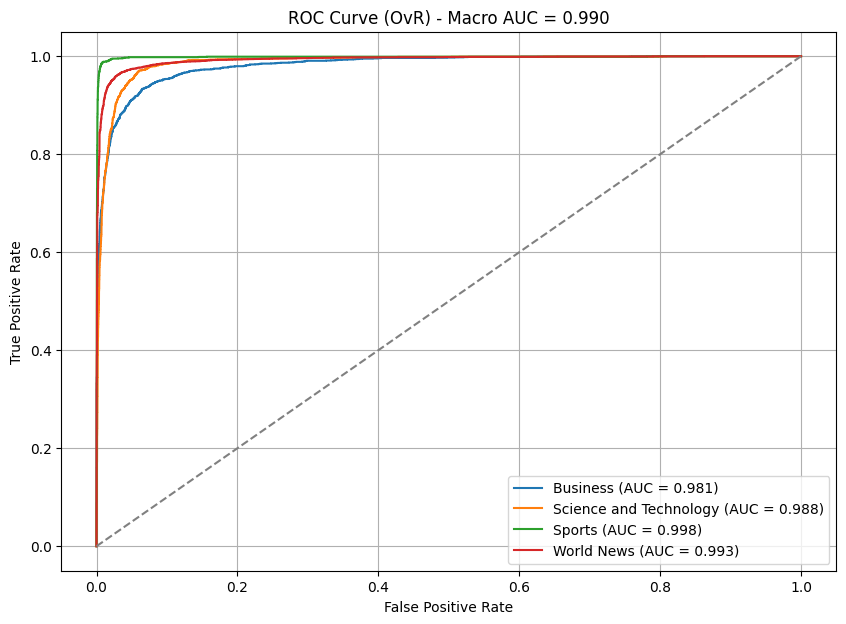

,Class,AUC
0,Business,0.9813
1,Science and Technology,0.9875
2,Sports,0.9982
3,World News,0.9928


Macro ROC-AUC: 0.9899


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# One-hot encoding of labels
y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute per-class ROC + AUC
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], final_test_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro AUC
macro_roc_auc = roc_auc_score(
    y_true_bin,
    final_test_prob,
    average="macro",
    multi_class="ovr"
)

# Plot
plt.figure(figsize=(10, 7))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title(f"ROC Curve (OvR) - Macro AUC = {macro_roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# AUC Table
roc_auc_df = pd.DataFrame({
    "Class": class_names,
    "AUC": [roc_auc[i] for i in range(n_classes)]
})

display(roc_auc_df.round(4))

print("Macro ROC-AUC:", round(macro_roc_auc, 4))

## 18.9 Micro vs Macro ROC Comparison

Micro-average ROC emphasizes instance-level performance and is influenced by larger classes. Macro-average ROC gives equal weight to every class, making it more suitable for judging balanced performance across categories.


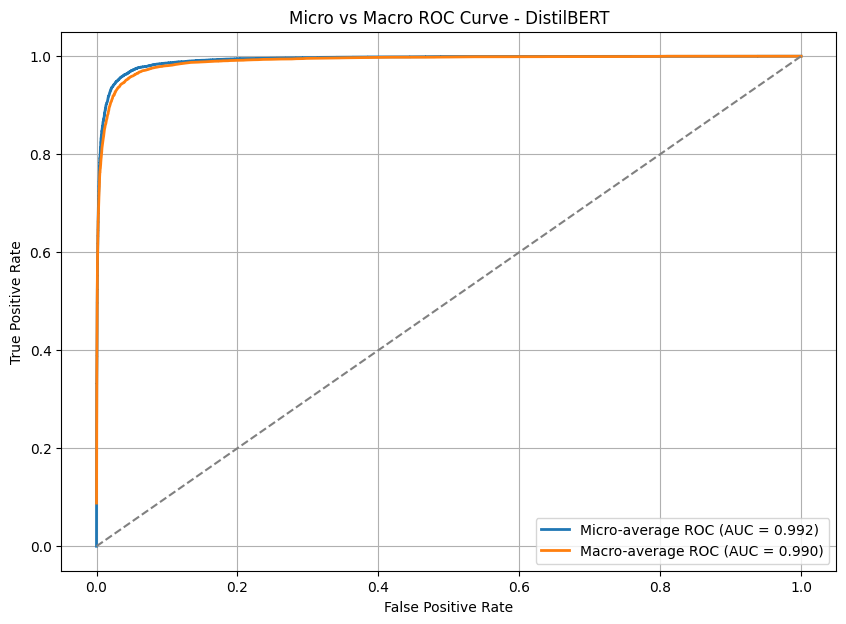

,ROC Type,AUC
0,Micro-average,0.9923
1,Macro-average,0.9900


In [40]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Micro-average
fpr_micro, tpr_micro, _ = roc_curve(
    y_true_bin.ravel(),
    final_test_prob.ravel()
)

roc_auc_micro = auc(fpr_micro, tpr_micro)

# Macro-average
all_fpr = np.unique(
    np.concatenate([fpr[i] for i in range(n_classes)])
)

mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr_macro = all_fpr
tpr_macro = mean_tpr
roc_auc_macro_curve = auc(fpr_macro, tpr_macro)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(
    fpr_micro,
    tpr_micro,
    label=f"Micro-average ROC (AUC = {roc_auc_micro:.3f})",
    linewidth=2
)

plt.plot(
    fpr_macro,
    tpr_macro,
    label=f"Macro-average ROC (AUC = {roc_auc_macro_curve:.3f})",
    linewidth=2
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title(f"Micro vs Macro ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Table
micro_macro_auc_df = pd.DataFrame([
    {"ROC Type": "Micro-average", "AUC": roc_auc_micro},
    {"ROC Type": "Macro-average", "AUC": roc_auc_macro_curve}
])

display(micro_macro_auc_df.round(4))

## 18.10 Final Test Summary

This final table presents the most important test-set metrics in a clean percentage format, followed by the classification report and confusion matrix.


In [41]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)

y_true = test_df["label"]
y_pred = final_test_pred

# -----------------------------
# Summary Metrics (in %)
# -----------------------------
final_summary_df = pd.DataFrame({
    "Metric": [
        "Final Accuracy (%)",
        "Balanced Accuracy (%)",
        "Macro Precision (%)",
        "Macro Recall (%)",
        "Macro F1 (%)",
        "Weighted F1 (%)"
    ],
    "Score": [
        accuracy_score(y_true, y_pred) * 100,
        balanced_accuracy_score(y_true, y_pred) * 100,
        precision_score(y_true, y_pred, average="macro") * 100,
        recall_score(y_true, y_pred, average="macro") * 100,
        f1_score(y_true, y_pred, average="macro") * 100,
        f1_score(y_true, y_pred, average="weighted") * 100
    ]
}).round(2)

# -----------------------------
# Classification Report (%)
# -----------------------------
final_report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).transpose()

for col in ["precision", "recall", "f1-score"]:
    final_report_df[col] = final_report_df[col] * 100

final_report_df = final_report_df.round(2)

# -----------------------------
# Confusion Matrix
# -----------------------------
final_cm = confusion_matrix(y_true, y_pred)

final_cm_df = pd.DataFrame(
    final_cm,
    index=[f"Actual: {label}" for label in class_names],
    columns=[f"Predicted: {label}" for label in class_names]
)

# -----------------------------
# Display
# -----------------------------
print("📊 Final Test Metric Summary:")
display(final_summary_df)

print("📑 Final Test Classification Report:")
display(final_report_df)

print("📉 Final Test Confusion Matrix:")
display(final_cm_df)

📊 Final Test Metric Summary:


,Metric,Score
0,Final Accuracy (%),93.56
1,Balanced Accuracy (%),92.48
2,Macro Precision (%),92.61
3,Macro Recall (%),92.48
4,Macro F1 (%),92.54
5,Weighted F1 (%),93.55


📑 Final Test Classification Report:


,precision,recall,f1-score,support
Business,86.88,85.54,86.20,2261.00
Science and Technology,90.01,90.43,90.22,3020.00
Sports,97.28,97.47,97.38,2056.00
World News,96.25,96.50,96.37,6648.00
accuracy,93.56,93.56,93.56,0.94
macro avg,92.61,92.48,92.54,13985.00
weighted avg,93.54,93.56,93.55,13985.00


📉 Final Test Confusion Matrix:


,Predicted: Business,Predicted: Science and Technology,Predicted: Sports,Predicted: World News
Actual: Business,1934,208,11,108
Actual: Science and Technology,178,2731,5,106
Actual: Sports,11,5,2004,36
Actual: World News,103,90,40,6415
